# Task 3: Análisis de Monte Carlo

- **INCISO A:** 
algoritmo Monte Carlo con  N = 5000 muestras para estimar la probabilidad de estabilidad del sistema de reorden. Use numpy para el muestreo.

Configuración inicial, muestreo de parámetros y cálculo de la probabilidad de estabilidad.

In [ ]:
# Presentación: "S5 - Retrasos y oscilaciones P2" 
# - Diapositiva 10: Algoritmo Monte Carlo implementado (N=5000).
# Se muestrean parámetros inciertos (alpha, tau) y se evalúa la condición de estabilidad P = alpha * tau.
# Presentación: "S5 - Retrasos y oscilaciones P2" 
# - Diapositiva 5: Límite de estabilidad usado (alpha * tau = pi/2).
# Presentación: "S4 - Retrasos y oscilaciones P1" 
# - Diapositiva 8: Modelado de tasas/distribuciones (tau muestreada con normal truncada; alpha uniforme como simplificación).
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configuración inicial
np.random.seed(42)
N = 5000
pi_2 = np.pi / 2

# Especificar distribuciones y muestrear alpha
alpha = np.random.uniform(0.25, 0.50, N)

# Muestrear tau (Normal truncada en cero)
tau = np.zeros(N)
for i in range(N):
    val = -1
    while val <= 0:  # Rechazar muestras negativas
        val = np.random.normal(3.5, 0.8)
    tau[i] = val

# Calcular el parámetro de estabilidad para cada par
P = alpha * tau

# Registrar casos estables e inestables (condición de la presentación S5: alpha * tau < pi/2)
es_estable = P < pi_2
prob_estable = np.mean(es_estable)

# Intervalo de confianza del 95% para la proporción (interpretación en S5 Diapositiva 11)
z = 1.96
error_estandar = np.sqrt((prob_estable * (1 - prob_estable)) / N)
lim_inf = prob_estable - z * error_estandar
lim_sup = prob_estable + z * error_estandar

print(f"Probabilidad de estabilidad estimada: {prob_estable:.4f}")
print(f"Intervalo de confianza (95%): [{lim_inf:.4f}, {lim_sup:.4f}]")

Probabilidad de estabilidad estimada: 0.7606
Intervalo de confianza (95%): [0.7488, 0.7724]


### Gráfica del histograma y cálculo de correlación

- **INCISO B:** rafique el histograma del producto $\alpha \cdot \tau$ sobre las 5000 muestras.

Visualización de los casos estables vs. inestables y análisis de sensibilidad de las variables.

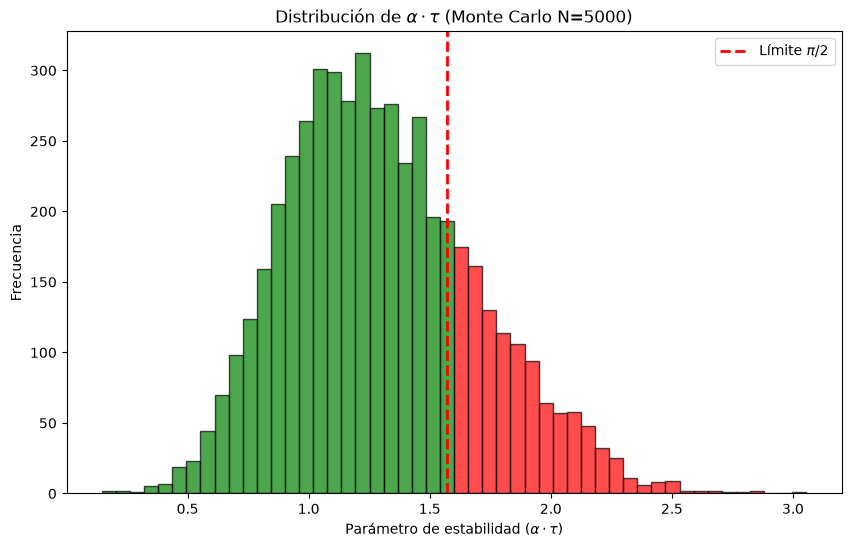

Correlación (alpha, P): 0.6168
Correlación (tau, P): 0.7558


In [ ]:
# Presentación: "S5 - Retrasos y oscilaciones P2" 
# - Diapositiva 10: Visualización del producto alpha * tau (histograma).
# Presentación: "S5 - Retrasos y oscilaciones P2" 
# - Diapositiva 5: Se marca el umbral alpha * tau = pi/2 para separar regiones estable/inestable.
# Presentación: "S5 - Retrasos y oscilaciones P2" 
# - Diapositiva 11: Interpretación Monte Carlo y análisis de sensibilidad (correlaciones entre variables).
# Presentación: "S4 - Retrasos y oscilaciones P1." 
# - Diapositiva 8: Relación con tasas/distribuciones al inspeccionar la forma del histograma.
# b) Graficar el histograma
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(P, bins=50, edgecolor='black', alpha=0.7)

# Sombrear las regiones verde (estable) y roja (inestable)
for c, p in zip(bins, patches):
    if c < pi_2:
        p.set_facecolor('green')
    else:
        p.set_facecolor('red')

# Marcar el umbral pi/2
plt.axvline(pi_2, color='red', linestyle='dashed', linewidth=2, label=r'Límite $\pi/2$')
plt.title('Distribución de $\\alpha \\cdot \\tau$ (Monte Carlo N=5000)')
plt.xlabel('Parámetro de estabilidad ($\\alpha \\cdot \\tau$)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# c) Correlación: medidas de sensibilidad entre variables (interpretación en Diapositiva 11)
corr_alpha_P = np.corrcoef(alpha, P)[0, 1]
corr_tau_P = np.corrcoef(tau, P)[0, 1]
print(f"Correlación (alpha, P): {corr_alpha_P:.4f}")
print(f"Correlación (tau, P): {corr_tau_P:.4f}")